In [1]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# ============================
# CARREGAR TODOS OS CSVs
# ============================

results_path = Path("")

csv_files = list(results_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("Nenhum CSV encontrado na pasta ../results")

dfs = []
for csv in csv_files:
    df_tmp = pd.read_csv(csv)
    df_tmp["source_file"] = csv.name  # opcional: rastrear origem
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

# 🔧 garantir que erro é numérico
df["erro"] = pd.to_numeric(df["erro"], errors="coerce")

# ============================
# ORDENAR MODELOS
# ============================

order = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# ============================
# MAPA DE CORES
# ============================

color_map = {
    "baseline_ultra":  "#EF553B",
    "shape_ultra":  "#EF553B",
    "tail_ultra":  "#EF553B",
    "divergence_ultra": "#EF553B",
    "qderiv_ultra": "#EF553B",
    "baseline_tails_01": "#EF553B",
    "DyS_hellinger": "#fc03d3",
    "DyS_topsoe": "#fc03d3",
    "QuaDapt_DyS": "#fc03d3",
    "baseline_lite": "#19D3F3",
    "mfe": "#19D3F3",
    "qderiv_lite": "#19D3F3",
    "MiniRocket": "#19D3F3",
    "tsfresh": "#19D3F3",
    "catch22": "#19D3F3",
    "divergence_lite": "#19D3F3",
    "tail_lite": "#19D3F3",
    "shape_lite": "#19D3F3"
}

# ============================
# PLOT
# ============================

fig = px.box(
    df,
    x="modelo",
    y="erro",
    category_orders={"modelo": order},
    points="all",
    color="modelo",
    color_discrete_map=color_map
)

fig.update_traces(
    jitter=0.35,
    marker=dict(size=4, opacity=0.6),
)

fig.update_layout(
    title="Comparação de erro entre modelos (ordenado do melhor ao pior)",
    xaxis_title="Modelo",
    yaxis_title="Erro absoluto |prev_pred − prev_real|",
    template="simple_white",
    width=950,
    height=450,
    showlegend=True
)

fig

In [2]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# ============================
# CARREGAR TODOS OS CSVs
# ============================

results_path = Path("")

csv_files = list(results_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "Nenhum CSV encontrado"
    )

dfs = []

for csv in csv_files:

    df_tmp = pd.read_csv(csv)

    df_tmp["source_file"] = csv.name

    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

# ============================
# LIMPEZA
# ============================

df["erro"] = pd.to_numeric(
    df["erro"],
    errors="coerce"
)

# ============================
# AGRUPAR TODOS OS MOSS
# ============================

df["grupo_modelo"] = df["modelo"]

df.loc[
    df["modelo"].str.contains(
        "MoSS",
        case=False,
        na=False
    ),
    "grupo_modelo"
] = "MoSS"

# ============================
# ORDEM DOS GRUPOS
# ============================

order = (
    df.groupby("grupo_modelo")["erro"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# ============================
# CORES
# ============================

color_map = {
    "MoSS": "#19D3F3",
    "EMQ_BCTS": "#EF553B",
    "ClusterQuant": "#AB63FA"
}

# ============================
# PLOT
# ============================

fig = px.box(
    df,
    x="grupo_modelo",
    y="erro",
    color="grupo_modelo",
    category_orders={
        "grupo_modelo": order
    },
    color_discrete_map=color_map,
    points="all"
)

fig.update_traces(
    jitter=0.35,
    marker=dict(
        size=4,
        opacity=0.5
    )
)

fig.update_layout(
    title=(
        "Comparação entre grupos de modelos"
    ),
    xaxis_title="Grupo",
    yaxis_title=(
        "Erro absoluto |prev_pred − prev_real|"
    ),
    template="simple_white",
    width=900,
    height=500,
    showlegend=False
)

fig.show()

# ============================
# SALVAR HTML
# ============================

fig.write_html(
    "comparacao_grupos.html"
)

print(
    "✅ HTML salvo em comparacao_grupos.html"
)

✅ HTML salvo em comparacao_grupos.html


In [3]:
# ============================
# TABELA DE MEDIANAS
# ============================

tabela_mediana = (
    df.groupby(
        ["dataset", "grupo_modelo"]
    )["erro"]
    .median()
    .reset_index()
)

# pivotar para ficar bonito
tabela_mediana = tabela_mediana.pivot(
    index="dataset",
    columns="grupo_modelo",
    values="erro"
)

# ordenar datasets pela melhor mediana do MoSS
if "MoSS" in tabela_mediana.columns:
    tabela_mediana = tabela_mediana.sort_values(
        by="MoSS"
    )

print("\n===== MEDIANA POR DATASET =====\n")

print(
    tabela_mediana.round(4)
)

# salvar CSV
tabela_mediana.to_csv(
    "medianas_por_dataset.csv"
)

print(
    "\n✅ Tabela salva em medianas_por_dataset.csv"
)


===== MEDIANA POR DATASET =====

grupo_modelo              AC      CC  ClusterQuant     EMQ  EMQ_BCTS      FM  \
dataset                                                                        
dry-bean.csv          0.0106  0.0114        0.0178  0.0086    0.0088  0.0176   
digits.csv            0.0042  0.0040        0.0171  0.0112    0.0119  0.0221   
isolet.csv            0.0045     NaN        0.0136  0.0084    0.0087  0.0293   
image_seg.csv         0.0057  0.0057        0.0367  0.0080    0.0082  0.0220   
hand_digits.csv       0.0027  0.0020        0.0146  0.0055    0.0059  0.0134   
letter.csv            0.0036     NaN        0.0231  0.0056    0.0060  0.0227   
chess.csv             0.0229  0.0240        0.0646  0.0190    0.0206  0.0427   
obesity.csv           0.0115  0.0114        0.0524  0.0190    0.0220  0.0428   
abalone.csv           0.1043  0.0818        0.0737  0.0755    0.0800  0.1159   
academic-success.csv  0.0810  0.1333        0.1658  0.0678    0.0700  0.3078   
molecu

In [4]:
import pandas as pd
import plotly.express as px

# =========================================================
# LOAD
# =========================================================
results_path = Path("")

csv_files = list(results_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("Nenhum CSV encontrado na pasta ../results")

dfs = []
for csv in csv_files:
    df_tmp = pd.read_csv(csv)
    df_tmp["source_file"] = csv.name  # opcional: rastrear origem
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

# 🔧 garantir que erro é numérico
df["erro"] = pd.to_numeric(df["erro"], errors="coerce")

# =========================================================
# AGREGAÇÃO (modelo × dataset)
# 👉 troque mean por median se quiser
# =========================================================
df_agg = (
    df
    .groupby(["modelo", "dataset"], as_index=False)
    .agg(erro_mean=("erro", "mean"))
)

# =========================================================
# ORDEM DOS MODELOS (melhor → pior)
# =========================================================
order = (
    df_agg
    .groupby("modelo")["erro_mean"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# =========================================================
# LINEPLOT
# =========================================================
fig = px.line(
    df_agg,
    x="dataset",
    y="erro_mean",
    color="modelo",
    category_orders={"modelo": order},
    markers=True
)

fig.update_layout(
    title="Erro médio por dataset (lineplot)",
    xaxis_title="Dataset",
    yaxis_title="Erro médio |prev_pred − prev_real|",
    template="simple_white",
    width=1100,
    height=500,
)

fig.update_traces(
    marker=dict(size=6),
    line=dict(width=2)
)

fig

In [2]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Carregar os dados
df = pd.read_csv("m_30_cluster_vs_emq_calibrated.csv")

# 2. Configurações de layout
datasets = df['dataset'].unique()
n_datasets = len(datasets)
# Criamos uma subfigura por dataset, em uma única coluna
fig = make_subplots(
    rows=n_datasets, cols=1, 
    subplot_titles=[f"<b>{ds}</b>" for ds in datasets],
    vertical_spacing=0.02 # Espaço curto entre os gráficos
)

# 3. Iterar e adicionar cada gráfico com sua própria ordem
for i, ds in enumerate(datasets, 1):
    df_ds = df[df['dataset'] == ds].copy()
    
    # Calcular a ordem local (pela mediana do erro neste dataset)
    ordem_local = df_ds.groupby("modelo")["erro"].median().sort_values().index.tolist()
    
    # Adicionar um boxplot para cada modelo, seguindo a ordem local
    for modelo in ordem_local:
        df_mod = df_ds[df_ds['modelo'] == modelo]
        fig.add_trace(
            go.Box(
                y=df_mod['erro'],
                name=modelo,
                boxpoints='outliers',
                legendgroup=modelo,
                showlegend=(i == 1) # Só mostra a legenda no primeiro gráfico
            ),
            row=i, col=1
        )

# 4. Ajustes finais de tamanho e estética
fig.update_layout(
    height=n_datasets * 400, # 300px para cada dataset
    template="plotly_white",
    title_text="Performance Local: Modelos Ordenados do Melhor para o Pior por Dataset",
    margin=dict(t=100, b=50, l=50, r=50),
    showlegend=True
)

# Deixar os eixos X independentes para cada subgráfico respeitar sua ordem
fig.update_xaxes(showgrid=False)
fig.update_yaxes(title_text="MAE")
fig.write_html("meu_resultado_ordenado.html")
fig.show()

In [2]:
mlquantify --version

NameError: name 'mlquantify' is not defined

       dataset    modelo  n_classes_original      erro
0  abalone.csv       EMQ                  11  0.078506
1  abalone.csv  EMQ_BCTS                  11  0.086898
2  abalone.csv        CC                  11  0.085455
3  abalone.csv       PCC                  11  0.078752
4  abalone.csv        AC                  11  0.126341

===== RANKING GLOBAL =====
                modelo      erro  rank
0   MoSS_10_CALIBRATED  0.002907     1
1   MoSS_26_CALIBRATED  0.004486     2
2   MoSS_15_CALIBRATED  0.009286     3
3    MoSS_7_CALIBRATED  0.012009     4
4   MoSS_11_CALIBRATED  0.036911     5
5               KDEyHD  0.040309     6
6               KDEyCS  0.042035     7
7               KDEyML  0.045995     8
8                  EMQ  0.046743     9
9                  PAC  0.046995    10
10            EMQ_BCTS  0.052457    11
11                  AC  0.058361    12
12                 PWK  0.062711    13
13                  CC  0.066963    14
14                 PCC  0.072456    15
15                

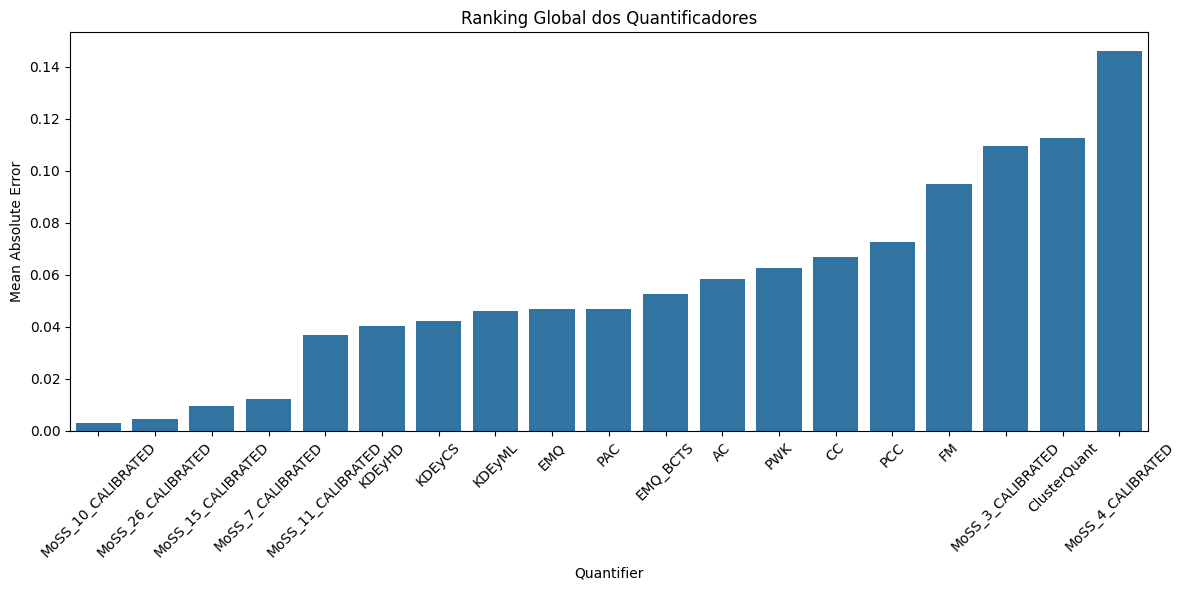


===== AVG RANK =====
                modelo  rank_dataset
0   MoSS_11_CALIBRATED      1.000000
1   MoSS_15_CALIBRATED      1.000000
2   MoSS_10_CALIBRATED      3.000000
3               KDEyML      3.500000
4    MoSS_7_CALIBRATED      4.000000
5   MoSS_26_CALIBRATED      4.500000
6               KDEyHD      5.277778
7                  EMQ      5.444444
8               KDEyCS      5.611111
9                  PAC      6.000000
10                  AC      6.166667
11   MoSS_4_CALIBRATED      6.500000
12                  CC      6.611111
13            EMQ_BCTS      6.666667
14                 PWK      7.888889
15   MoSS_3_CALIBRATED      8.571429
16                 PCC      9.444444
17                  FM     11.166667
18        ClusterQuant     11.555556


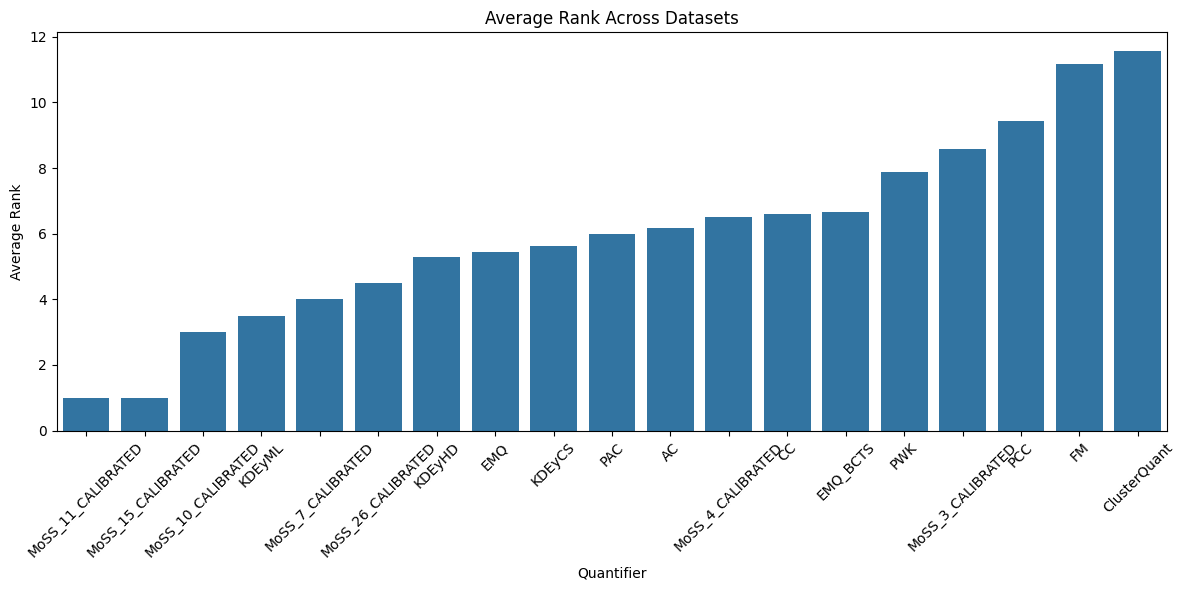

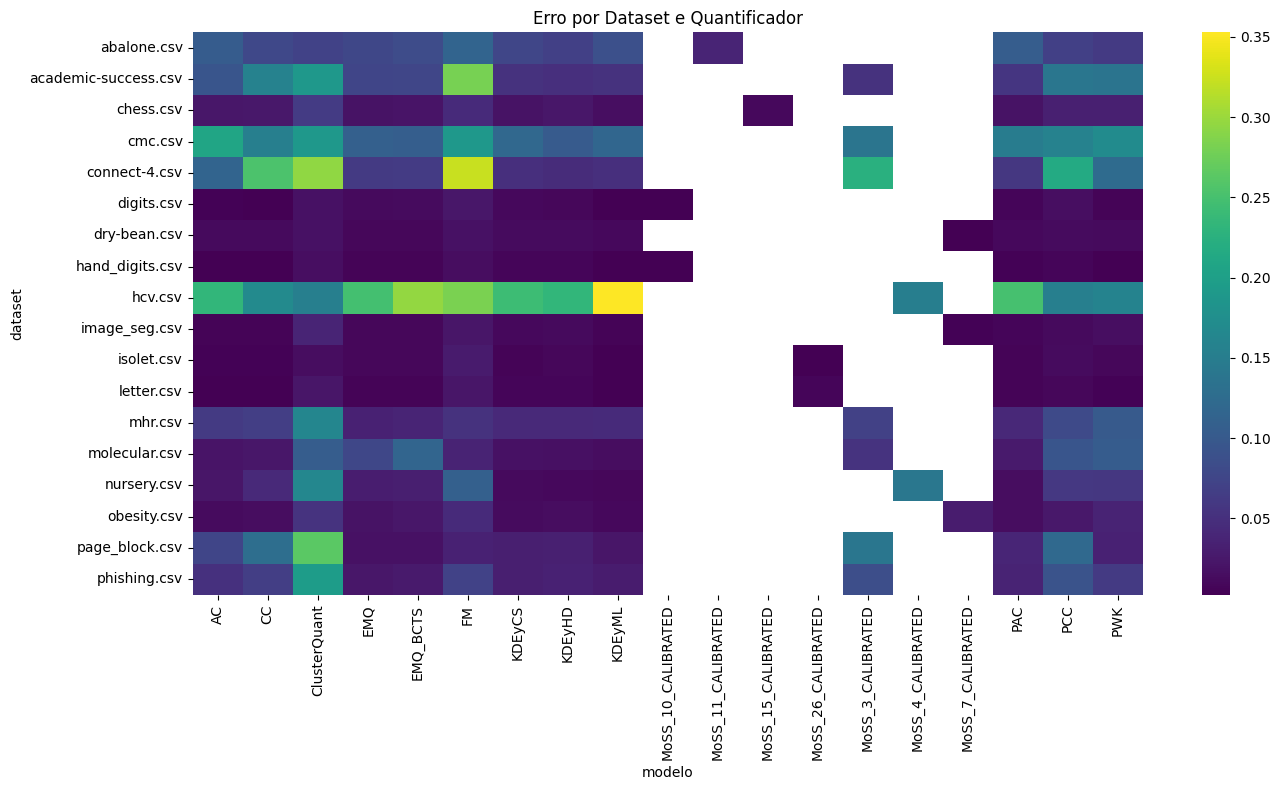


===== WIN COUNTS =====
               modelo  wins
0              KDEyML     5
1              KDEyHD     3
2                 EMQ     2
3   MoSS_7_CALIBRATED     2
4  MoSS_11_CALIBRATED     1
5  MoSS_10_CALIBRATED     1
6  MoSS_15_CALIBRATED     1
7   MoSS_4_CALIBRATED     1
8  MoSS_26_CALIBRATED     1
9            EMQ_BCTS     1


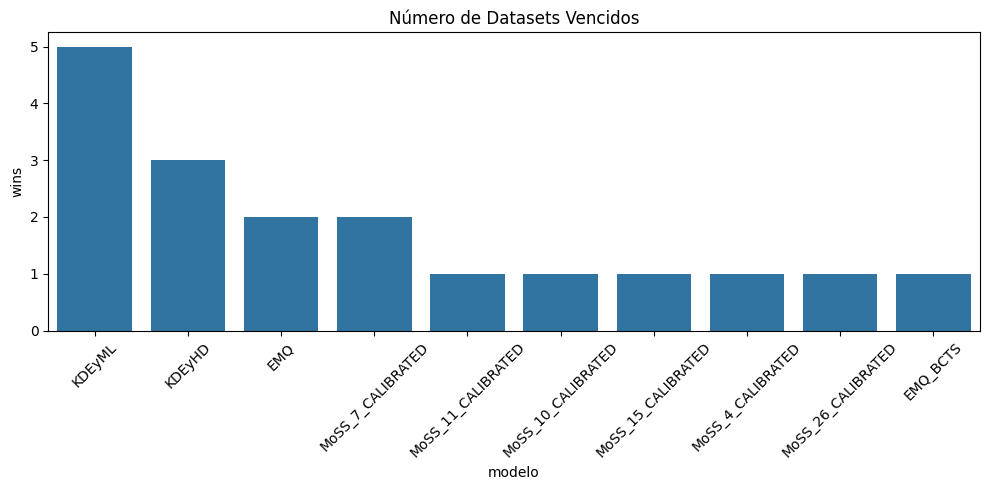

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD
# ============================================================

CSV_PATH = "all_quantifiers_vs_moss.csv"

df = pd.read_csv(CSV_PATH)

print(df.head())

# ============================================================
# MÉDIA GLOBAL DE ERRO
# ============================================================

ranking = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

ranking["rank"] = np.arange(1, len(ranking) + 1)

print("\n===== RANKING GLOBAL =====")
print(ranking)

# ============================================================
# SALVAR TABELA
# ============================================================

ranking.to_csv(
    "ranking_global.csv",
    index=False
)

# ============================================================
# GRÁFICO DE BARRAS
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=ranking,
    x="modelo",
    y="erro"
)

plt.xticks(rotation=45)
plt.ylabel("Mean Absolute Error")
plt.xlabel("Quantifier")
plt.title("Ranking Global dos Quantificadores")

plt.tight_layout()

plt.savefig(
    "ranking_global.png",
    dpi=300
)

plt.show()

# ============================================================
# RANKING POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# rank dentro de cada dataset
dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# RANK MÉDIO FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVG RANK =====")
print(avg_rank)

avg_rank.to_csv(
    "average_rank.csv",
    index=False
)

# ============================================================
# GRÁFICO AVG RANK
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=avg_rank,
    x="modelo",
    y="rank_dataset"
)

plt.xticks(rotation=45)

plt.ylabel("Average Rank")
plt.xlabel("Quantifier")

plt.title("Average Rank Across Datasets")

plt.tight_layout()

plt.savefig(
    "average_rank.png",
    dpi=300
)

plt.show()

# ============================================================
# HEATMAP
# ============================================================

pivot = dataset_mean.pivot(
    index="dataset",
    columns="modelo",
    values="erro"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    pivot,
    cmap="viridis",
    annot=False
)

plt.title("Erro por Dataset e Quantificador")

plt.tight_layout()

plt.savefig(
    "heatmap_quantifiers.png",
    dpi=300
)

plt.show()

# ============================================================
# WIN COUNTS
# ============================================================

wins = (
    dataset_mean.loc[
        dataset_mean.groupby("dataset")["erro"].idxmin()
    ]["modelo"]
    .value_counts()
    .reset_index()
)

wins.columns = ["modelo", "wins"]

print("\n===== WIN COUNTS =====")
print(wins)

wins.to_csv(
    "wins.csv",
    index=False
)

# ============================================================
# GRÁFICO DE VITÓRIAS
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=wins,
    x="modelo",
    y="wins"
)

plt.xticks(rotation=45)

plt.title("Número de Datasets Vencidos")

plt.tight_layout()

plt.savefig(
    "wins.png",
    dpi=300
)

plt.show()


===== CSV LOADED =====
       dataset    modelo  n_classes_original      erro
0  abalone.csv       EMQ                  11  0.078506
1  abalone.csv  EMQ_BCTS                  11  0.086898
2  abalone.csv        CC                  11  0.085455
3  abalone.csv       PCC                  11  0.078752
4  abalone.csv        AC                  11  0.126341

===== MODELOS =====
['AC', 'CC', 'ClusterQuant', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'MoSS_CALIBRATED', 'PAC', 'PCC', 'PWK']

===== DATASETS POR MODELO =====
modelo
AC                 18
CC                 18
ClusterQuant       18
EMQ                18
EMQ_BCTS           18
FM                 18
KDEyCS             18
KDEyHD             18
KDEyML             18
MoSS_CALIBRATED    18
PAC                18
PCC                18
PWK                18
Name: dataset, dtype: int64

===== RANKING GLOBAL =====
             modelo      erro  rank
0            KDEyHD  0.040309     1
1            KDEyCS  0.042035     2
2          

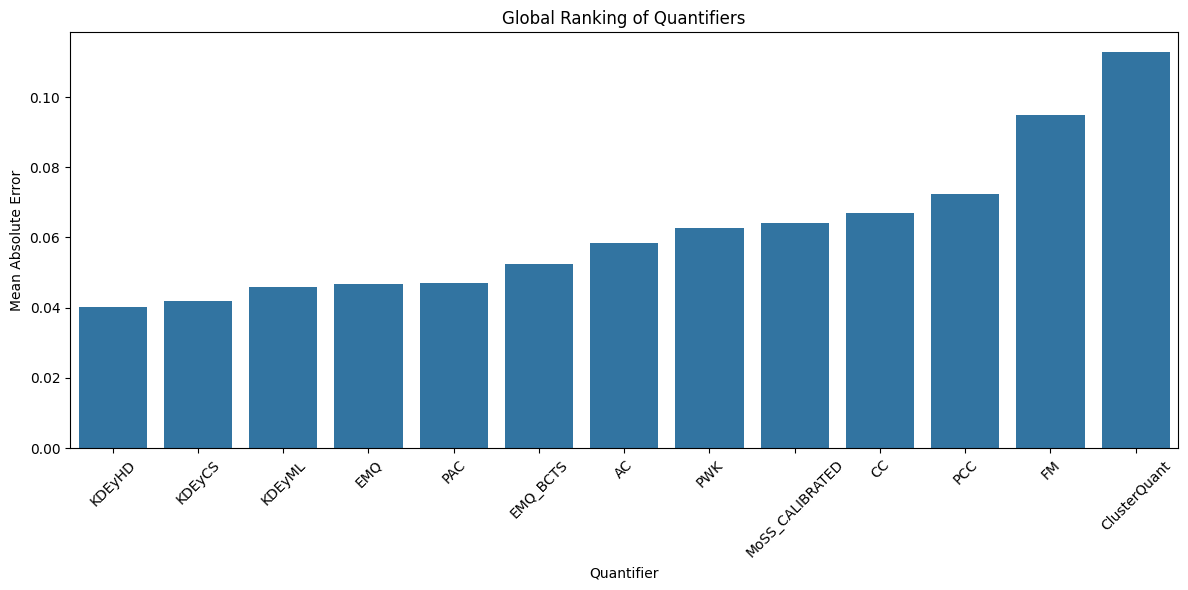


===== AVERAGE RANK =====
             modelo  rank_dataset
0            KDEyML      3.500000
1            KDEyHD      5.277778
2               EMQ      5.444444
3            KDEyCS      5.611111
4   MoSS_CALIBRATED      5.666667
5               PAC      6.000000
6                AC      6.166667
7                CC      6.611111
8          EMQ_BCTS      6.666667
9               PWK      7.888889
10              PCC      9.444444
11               FM     11.166667
12     ClusterQuant     11.555556


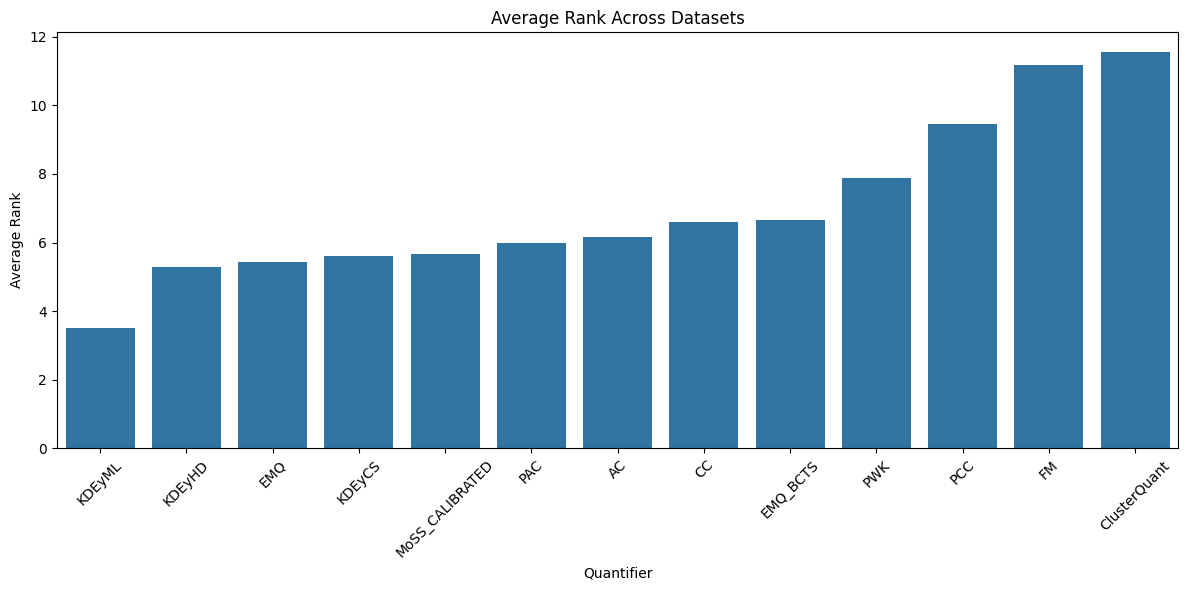

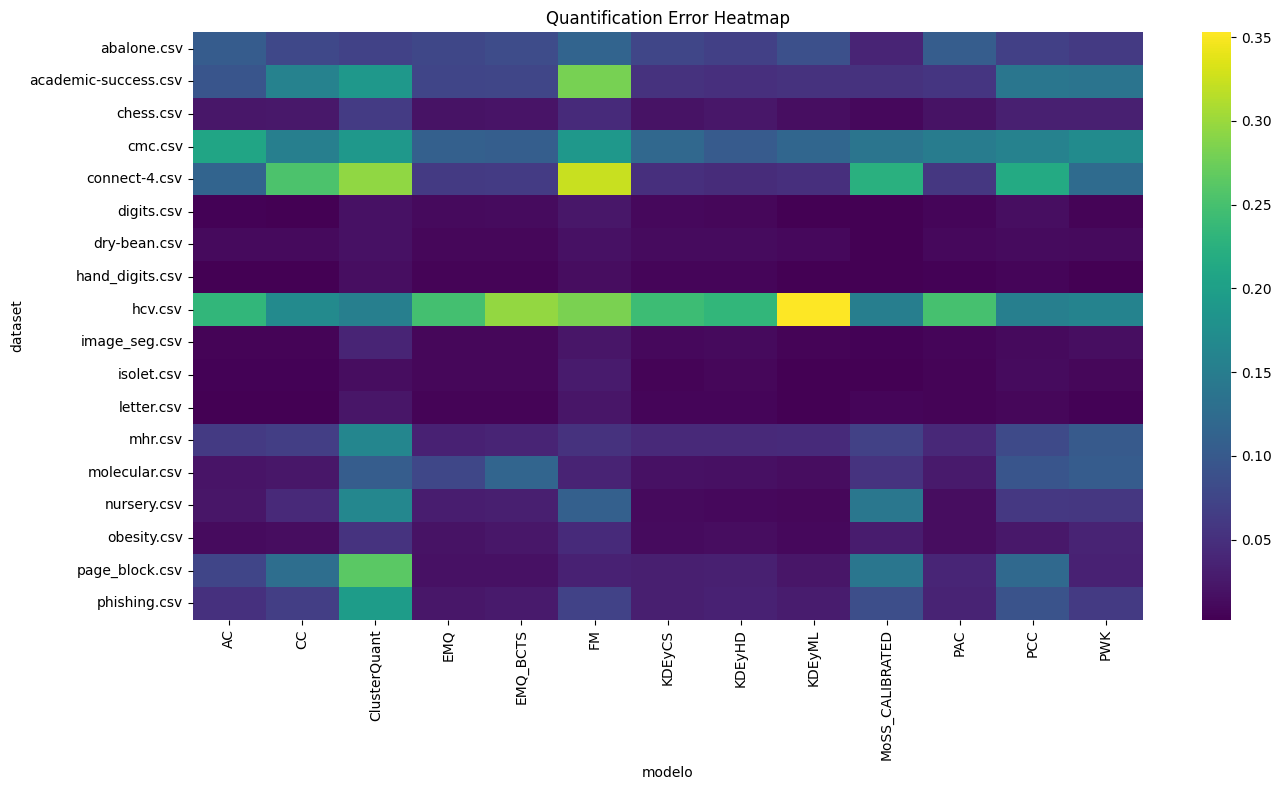


===== WIN COUNTS =====
            modelo  wins
0  MoSS_CALIBRATED     7
1           KDEyML     5
2           KDEyHD     3
3              EMQ     2
4         EMQ_BCTS     1


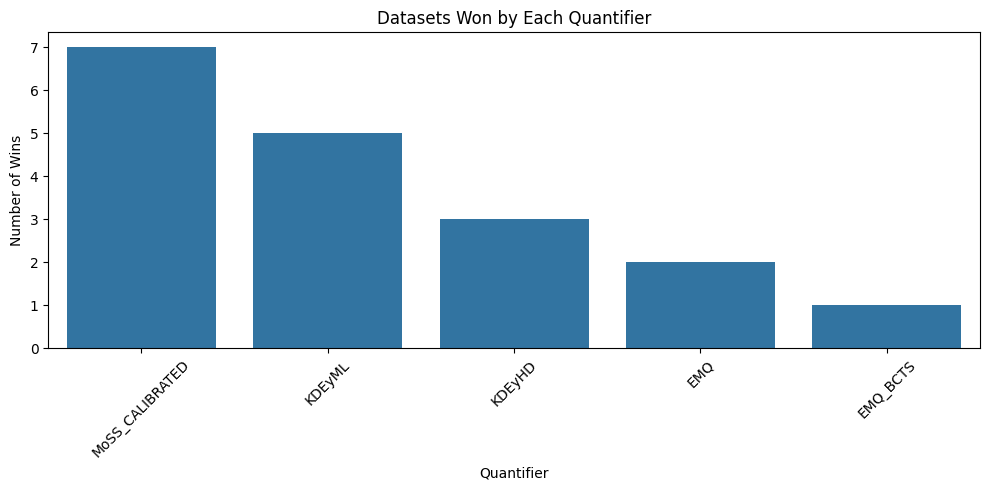


✅ ANALYSIS FINISHED

Arquivos gerados:
 - ranking_global.csv
 - ranking_global.png
 - average_rank.csv
 - average_rank.png
 - heatmap_quantifiers.png
 - wins.csv
 - wins.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "all_quantifiers_vs_moss.csv"

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

print("\n===== MODELOS =====")
print(sorted(df["modelo"].unique()))

# ============================================================
# CHECAR QUANTOS DATASETS CADA MODELO POSSUI
# ============================================================

dataset_counts = (
    df.groupby("modelo")["dataset"]
    .nunique()
    .sort_values(ascending=False)
)

print("\n===== DATASETS POR MODELO =====")
print(dataset_counts)

# ============================================================
# RANKING GLOBAL
# ============================================================

ranking = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

ranking["rank"] = np.arange(1, len(ranking) + 1)

print("\n===== RANKING GLOBAL =====")
print(ranking)

# ============================================================
# SALVAR RANKING
# ============================================================

ranking.to_csv(
    "ranking_global.csv",
    index=False
)

# ============================================================
# GRÁFICO RANKING GLOBAL
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=ranking,
    x="modelo",
    y="erro"
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Mean Absolute Error")

plt.title("Global Ranking of Quantifiers")

plt.tight_layout()

plt.savefig(
    "ranking_global.png",
    dpi=300
)

plt.show()

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

avg_rank.to_csv(
    "average_rank.csv",
    index=False
)

# ============================================================
# GRÁFICO AVG RANK
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=avg_rank,
    x="modelo",
    y="rank_dataset"
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Average Rank")

plt.title("Average Rank Across Datasets")

plt.tight_layout()

plt.savefig(
    "average_rank.png",
    dpi=300
)

plt.show()

# ============================================================
# HEATMAP
# ============================================================

pivot = dataset_mean.pivot(
    index="dataset",
    columns="modelo",
    values="erro"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    pivot,
    cmap="viridis",
    annot=False
)

plt.title("Quantification Error Heatmap")

plt.tight_layout()

plt.savefig(
    "heatmap_quantifiers.png",
    dpi=300
)

plt.show()

# ============================================================
# WIN COUNTS
# ============================================================

wins = (
    dataset_mean.loc[
        dataset_mean.groupby("dataset")["erro"].idxmin()
    ]["modelo"]
    .value_counts()
    .reset_index()
)

wins.columns = ["modelo", "wins"]

print("\n===== WIN COUNTS =====")
print(wins)

# ============================================================
# SALVAR WINS
# ============================================================

wins.to_csv(
    "wins.csv",
    index=False
)

# ============================================================
# GRÁFICO DE VITÓRIAS
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=wins,
    x="modelo",
    y="wins"
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Number of Wins")

plt.title("Datasets Won by Each Quantifier")

plt.tight_layout()

plt.savefig(
    "wins.png",
    dpi=300
)

plt.show()

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - ranking_global.csv")
print(" - ranking_global.png")

print(" - average_rank.csv")
print(" - average_rank.png")

print(" - heatmap_quantifiers.png")

print(" - wins.csv")
print(" - wins.png")


===== CSV LOADED =====
       dataset    modelo  n_classes_original      erro
0  abalone.csv       EMQ                  11  0.078506
1  abalone.csv  EMQ_BCTS                  11  0.086898
2  abalone.csv        CC                  11  0.085455
3  abalone.csv       PCC                  11  0.078752
4  abalone.csv        AC                  11  0.126341

===== MODELOS =====
['AC', 'CC', 'ClusterQuant', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'MoSS_CALIBRATED', 'PAC', 'PCC', 'PWK']

===== AVERAGE RANK =====
             modelo  rank_dataset
0            KDEyML      3.500000
1            KDEyHD      5.277778
2               EMQ      5.444444
3            KDEyCS      5.611111
4   MoSS_CALIBRATED      5.666667
5               PAC      6.000000
6                AC      6.166667
7                CC      6.611111
8          EMQ_BCTS      6.666667
9               PWK      7.888889
10              PCC      9.444444
11               FM     11.166667
12     ClusterQuant     11.555556

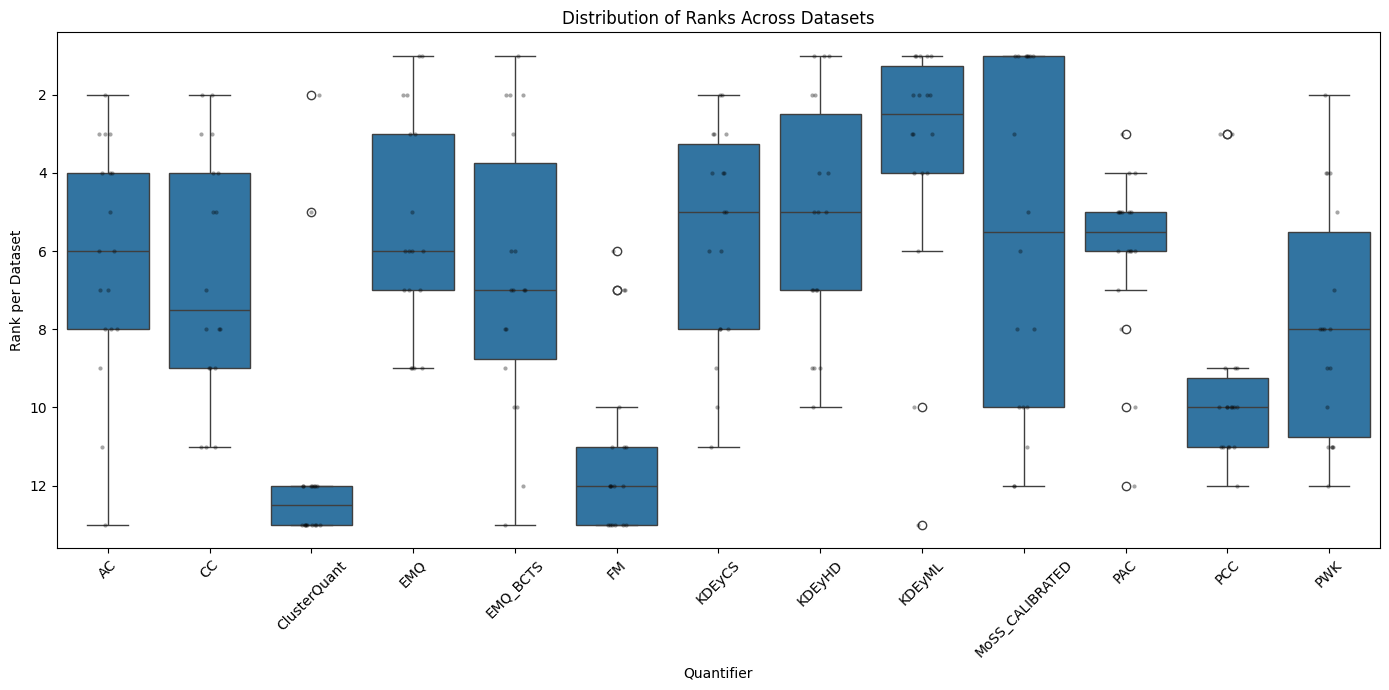

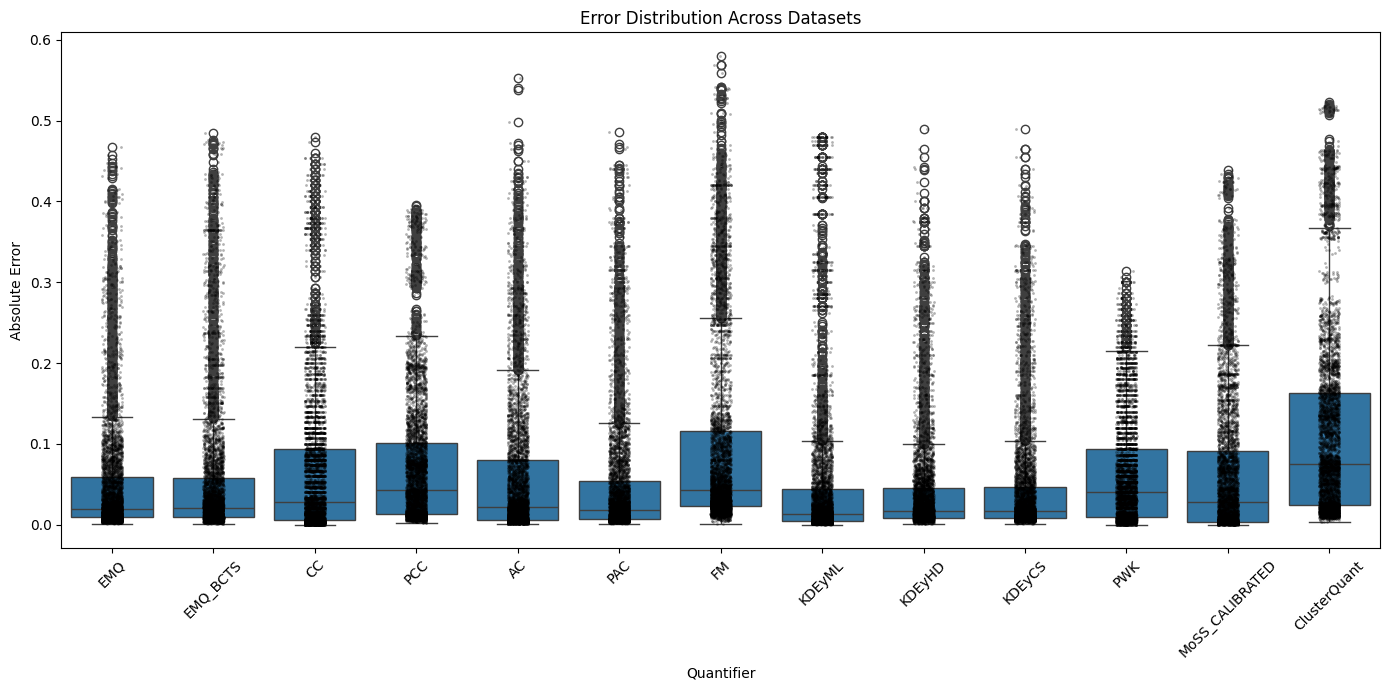


✅ ANALYSIS FINISHED

Arquivos gerados:
 - average_rank.csv
 - rank_boxplot.png
 - error_boxplot.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "all_quantifiers_vs_moss.csv"

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

print("\n===== MODELOS =====")
print(sorted(df["modelo"].unique()))

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

avg_rank.to_csv(
    "average_rank.csv",
    index=False
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset"
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title("Distribution of Ranks Across Datasets")

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "rank_boxplot.png",
    dpi=300
)

plt.show()

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro"
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title("Error Distribution Across Datasets")

plt.tight_layout()

plt.savefig(
    "error_boxplot.png",
    dpi=300
)

plt.show()

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank.csv")
print(" - rank_boxplot.png")
print(" - error_boxplot.png")


===== CSV LOADED =====
       dataset    modelo  n_classes_original      erro
0  abalone.csv       EMQ                  11  0.078506
1  abalone.csv  EMQ_BCTS                  11  0.086898
2  abalone.csv        CC                  11  0.085455
3  abalone.csv       PCC                  11  0.078752
4  abalone.csv        AC                  11  0.126341

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'FM', 'KDEyML', 'MoSS_CALIBRATED', 'PAC', 'PCC', 'PWK']

===== AVERAGE RANK =====
            modelo  rank_dataset
0           KDEyML      2.388889
1              EMQ      4.166667
2  MoSS_CALIBRATED      4.222222
3               AC      4.388889
4              PAC      4.388889
5               CC      4.833333
6              PWK      5.888889
7              PCC      6.833333
8               FM      7.888889


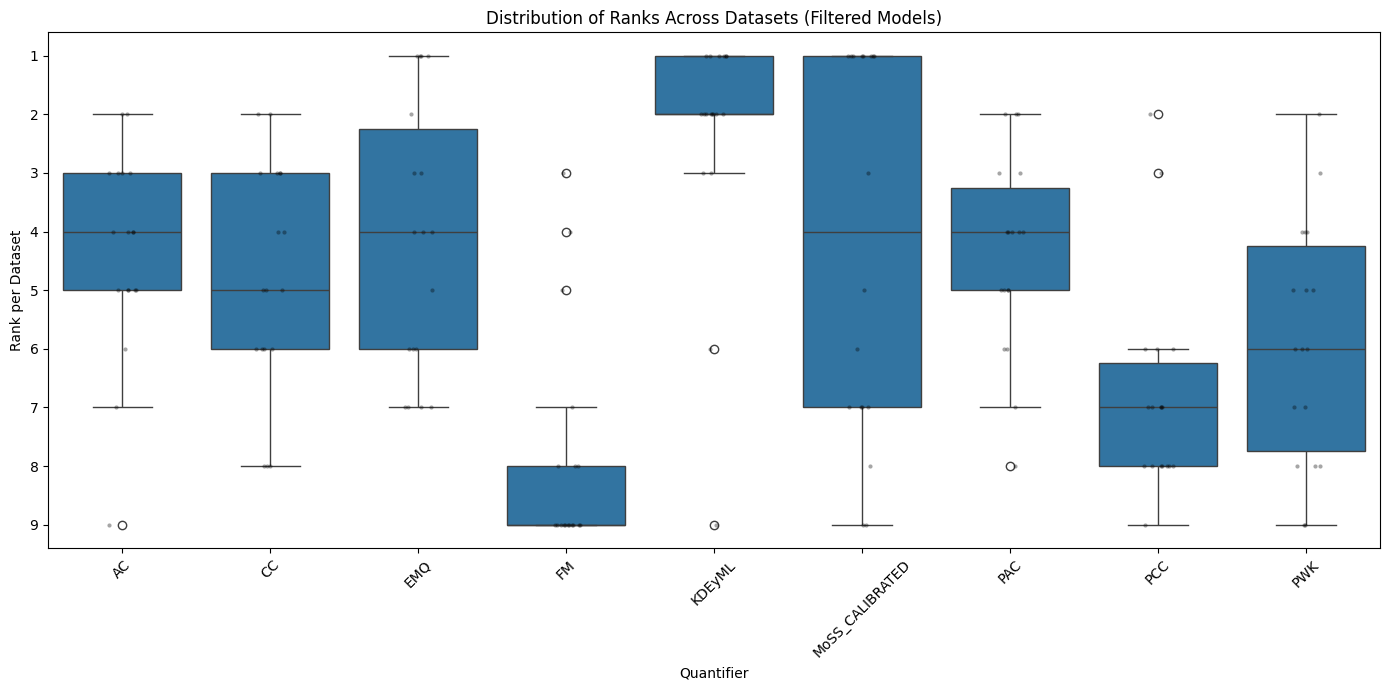

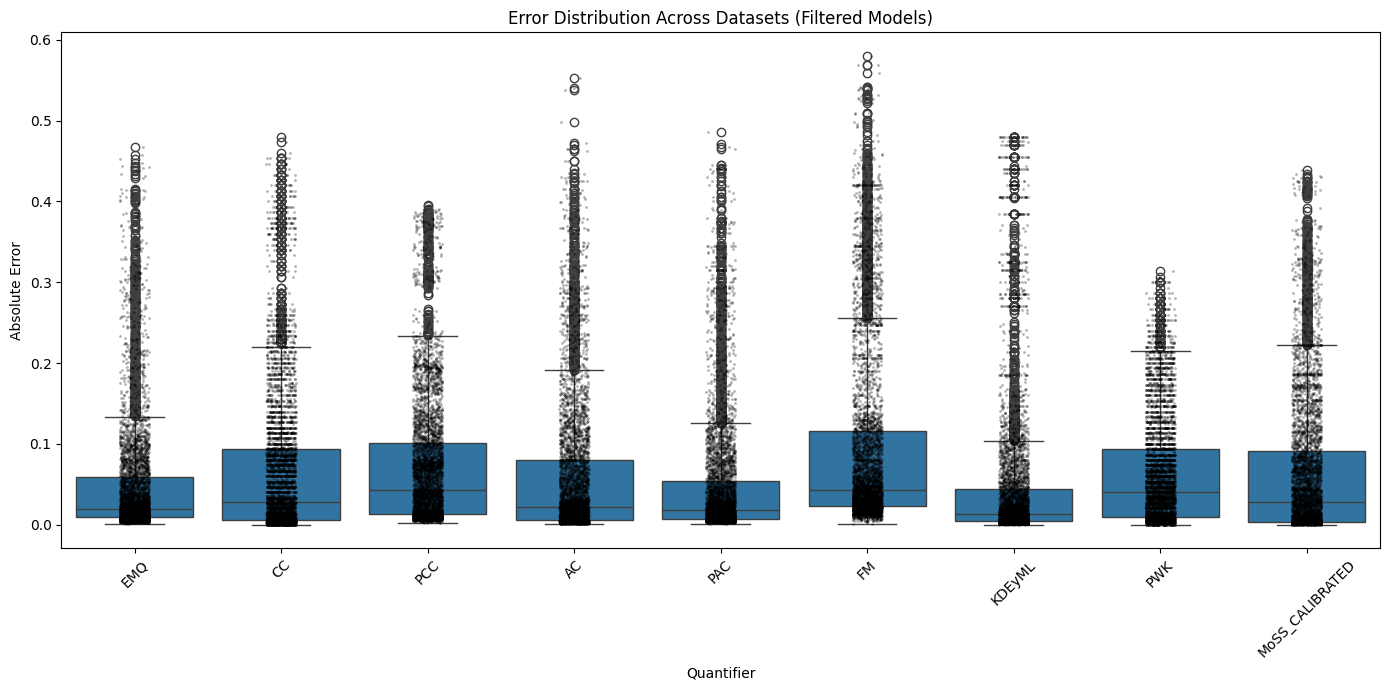


===== GLOBAL MEAN ERROR =====
            modelo  mean_error
0           KDEyML    0.045995
1              EMQ    0.046743
2              PAC    0.046995
3               AC    0.058361
4              PWK    0.062711
5  MoSS_CALIBRATED    0.064250
6               CC    0.066963
7              PCC    0.072456
8               FM    0.094859

✅ ANALYSIS FINISHED

Arquivos gerados:
 - average_rank_filtered.csv
 - global_mean_error_filtered.csv
 - rank_boxplot_filtered.png
 - error_boxplot_filtered.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "all_quantifiers_vs_moss.csv"

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

# ============================================================
# REMOVER MODELOS ESPECÍFICOS
# ============================================================

modelos_remover = [
    "KDEyHD",
    "KDEyCS",
    "EMQ_BCTS",
    "ClusterQuant"
]

df = df[~df["modelo"].isin(modelos_remover)]

print("\n===== MODELOS RESTANTES =====")
print(sorted(df["modelo"].unique()))

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

avg_rank.to_csv(
    "average_rank_filtered.csv",
    index=False
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset"
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title("Distribution of Ranks Across Datasets (Filtered Models)")

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "rank_boxplot_filtered.png",
    dpi=300
)

plt.show()

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro"
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title("Error Distribution Across Datasets (Filtered Models)")

plt.tight_layout()

plt.savefig(
    "error_boxplot_filtered.png",
    dpi=300
)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = ["modelo", "mean_error"]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# SALVAR RESULTADOS
# ============================================================

global_mean_error.to_csv(
    "global_mean_error_filtered.csv",
    index=False
)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")


===== CSV LOADED =====
       dataset    modelo  n_classes_original      erro
0  abalone.csv       EMQ                  11  0.078506
1  abalone.csv  EMQ_BCTS                  11  0.086898
2  abalone.csv        CC                  11  0.085455
3  abalone.csv       PCC                  11  0.078752
4  abalone.csv        AC                  11  0.126341

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'FM', 'KDEyML', 'MoSS_CALIBRATED', 'PAC', 'PCC', 'PWK']

===== AVERAGE RANK =====
            modelo  rank_dataset
0           KDEyML      2.388889
1              EMQ      4.166667
2  MoSS_CALIBRATED      4.222222
3               AC      4.388889
4              PAC      4.388889
5               CC      4.833333
6              PWK      5.888889
7              PCC      6.833333
8               FM      7.888889


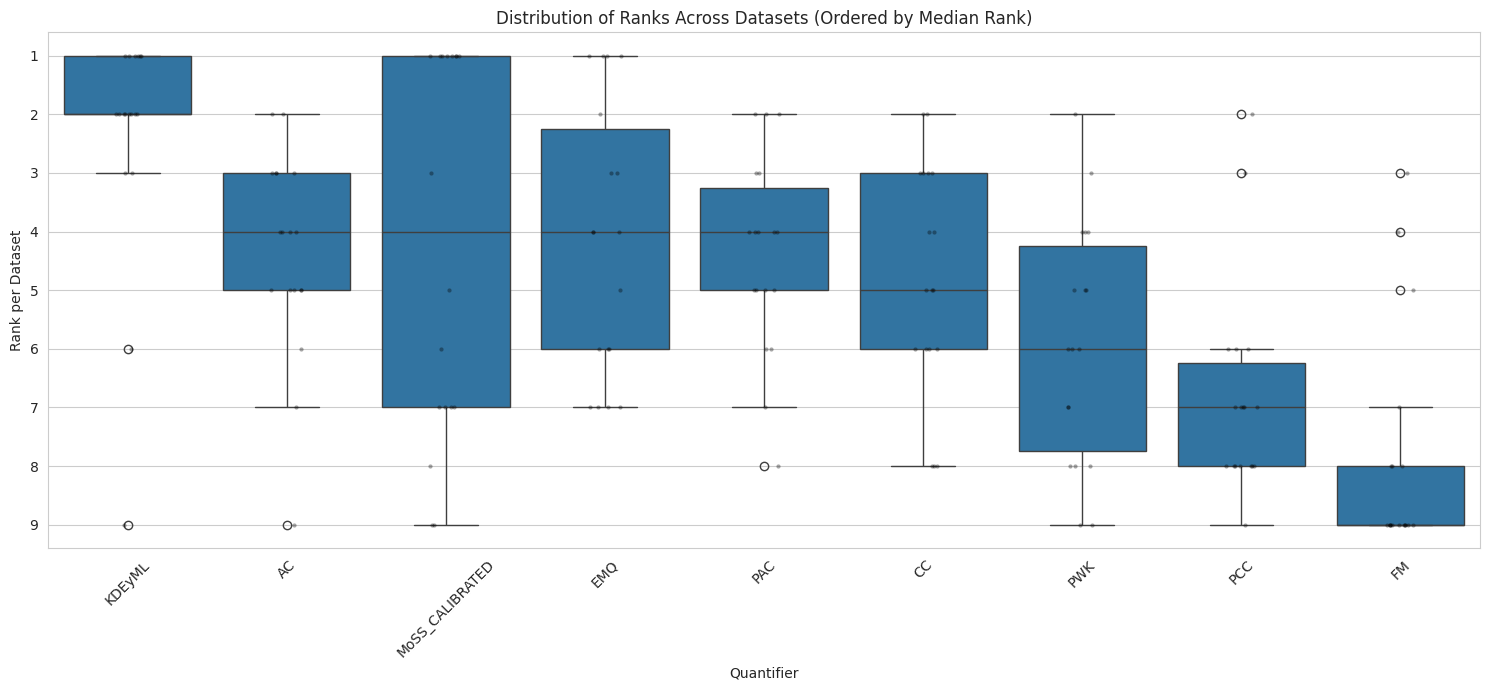

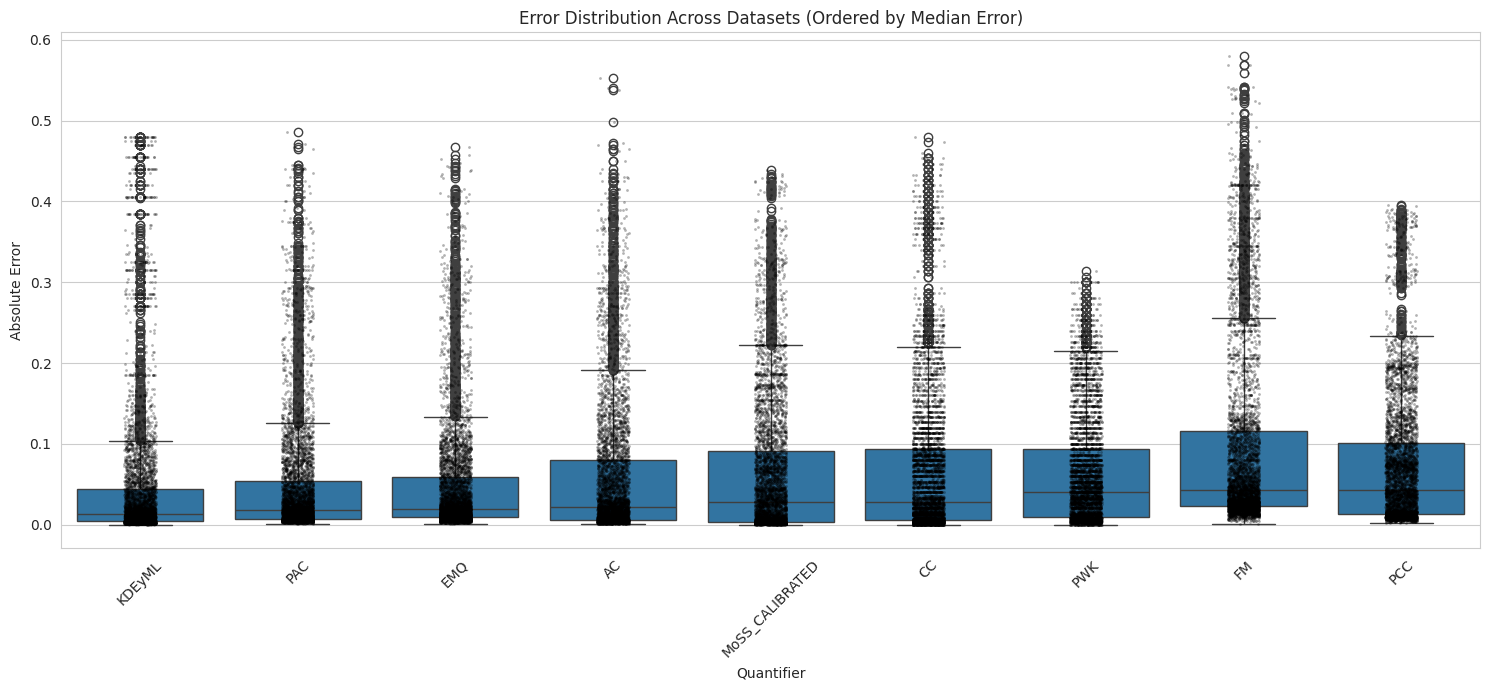


===== GLOBAL MEAN ERROR =====
            modelo  mean_error
0           KDEyML    0.045995
1              EMQ    0.046743
2              PAC    0.046995
3               AC    0.058361
4              PWK    0.062711
5  MoSS_CALIBRATED    0.064250
6               CC    0.066963
7              PCC    0.072456
8               FM    0.094859

===== GLOBAL MEDIAN ERROR =====
            modelo  median_error
0           KDEyML      0.013014
1              PAC      0.018216
2              EMQ      0.019955
3               AC      0.021630
4  MoSS_CALIBRATED      0.027778
5               CC      0.028571
6              PWK      0.040000
7               FM      0.042743
8              PCC      0.042811

✅ ANALYSIS FINISHED

Arquivos gerados:
 - average_rank_filtered.csv
 - global_mean_error_filtered.csv
 - global_median_error_filtered.csv
 - rank_boxplot_filtered.png
 - error_boxplot_filtered.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "all_quantifiers_vs_moss.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

# ============================================================
# REMOVER MODELOS ESPECÍFICOS
# ============================================================

modelos_remover = [
    "KDEyHD",
    "KDEyCS",
    "EMQ_BCTS",
    "ClusterQuant"
]

df = df[~df["modelo"].isin(modelos_remover)]

print("\n===== MODELOS RESTANTES =====")
print(sorted(df["modelo"].unique()))

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

avg_rank.to_csv(
    "average_rank_filtered.csv",
    index=False
)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "rank_boxplot_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

plt.savefig(
    "error_boxplot_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR =====")
print(global_median_error)

# ============================================================
# SALVAR RESULTADOS
# ============================================================

global_mean_error.to_csv(
    "global_mean_error_filtered.csv",
    index=False
)

global_median_error.to_csv(
    "global_median_error_filtered.csv",
    index=False
)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")


===== CSV LOADED =====
       dataset    modelo  n_classes_original      erro
0  abalone.csv       EMQ                  11  0.078506
1  abalone.csv  EMQ_BCTS                  11  0.086898
2  abalone.csv        CC                  11  0.085455
3  abalone.csv       PCC                  11  0.078752
4  abalone.csv        AC                  11  0.126341

Total original datasets: 18

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'FM', 'KDEyML', 'MoSS_CALIBRATED', 'PAC', 'PCC', 'PWK']

Total remaining models: 9

Datasets completos restantes: 18

✅ Todos os datasets possuem todos os modelos restantes.

===== AVERAGE RANK =====
            modelo  rank_dataset
0           KDEyML      2.388889
1              EMQ      4.166667
2  MoSS_CALIBRATED      4.222222
3               AC      4.388889
4              PAC      4.388889
5               CC      4.833333
6              PWK      5.888889
7              PCC      6.833333
8               FM      7.888889


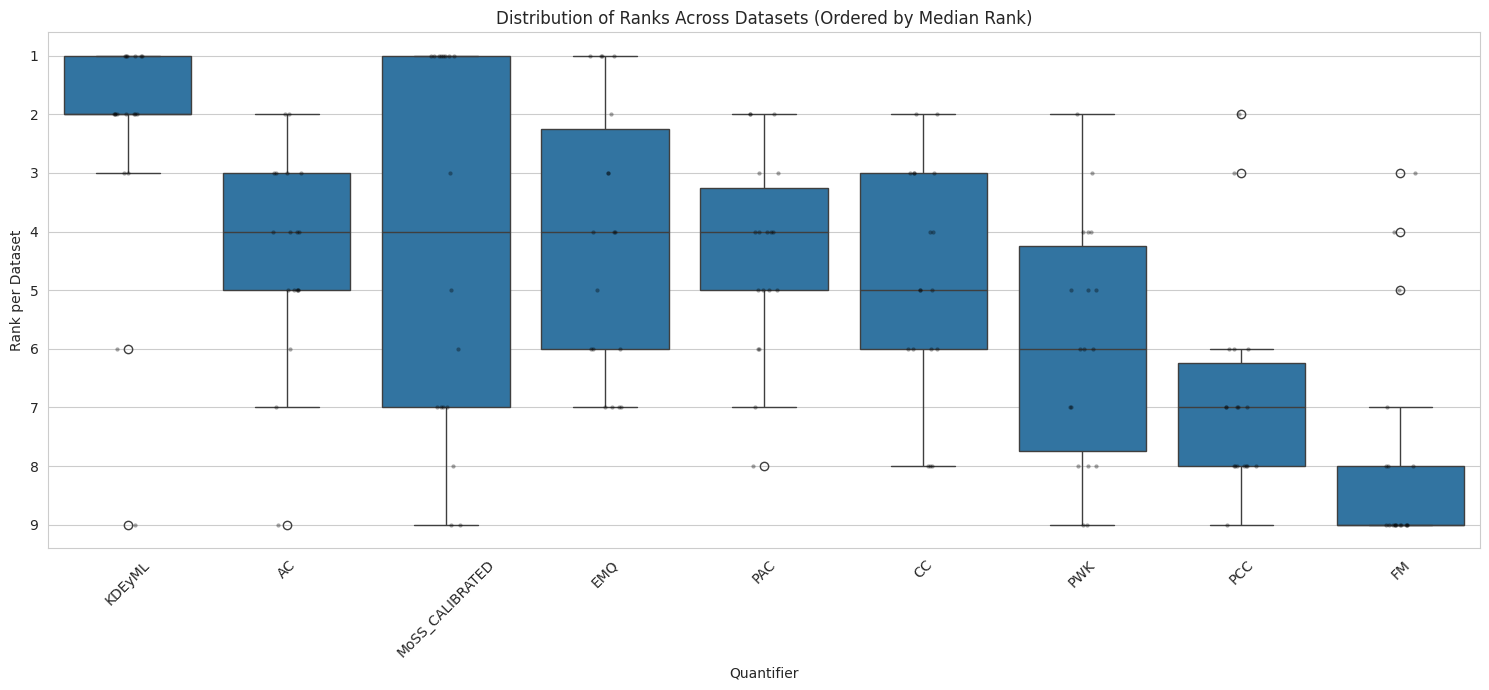

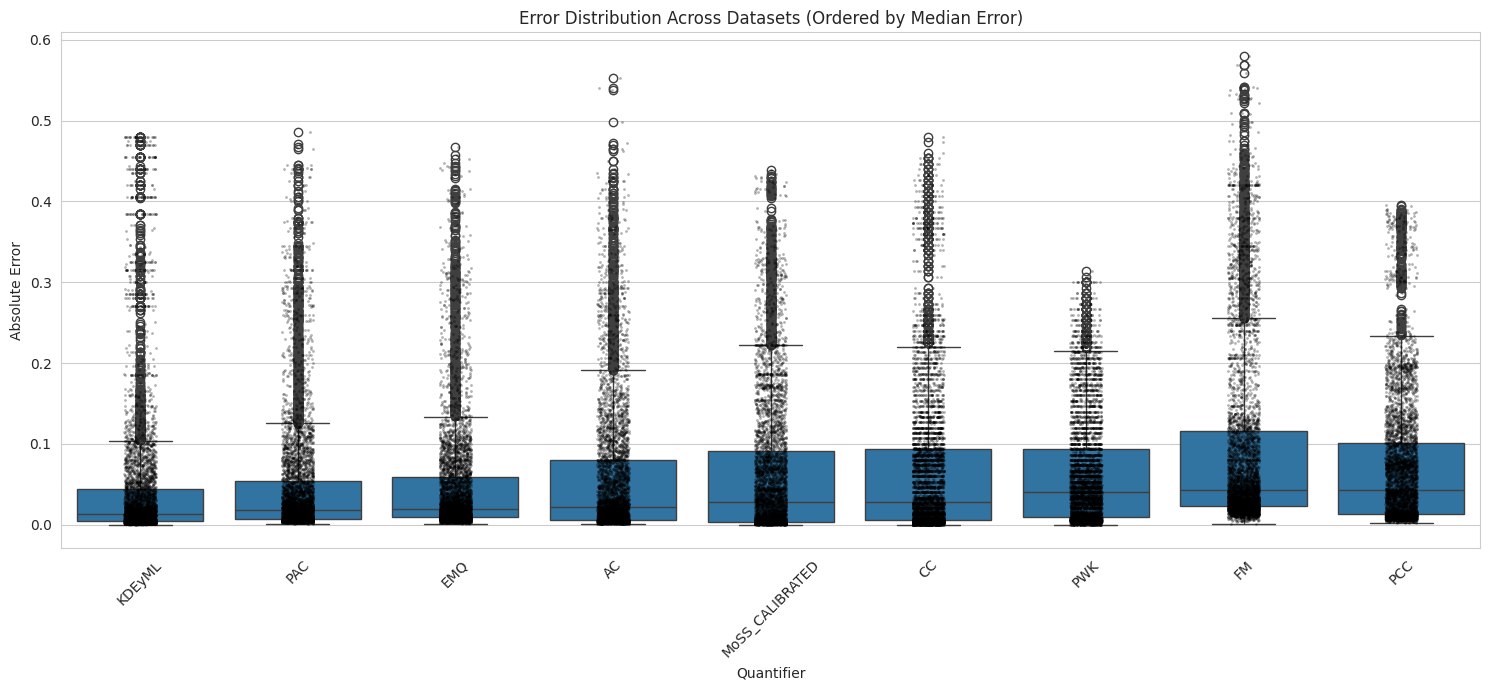


===== GLOBAL MEAN ERROR =====
            modelo  mean_error
0           KDEyML    0.045995
1              EMQ    0.046743
2              PAC    0.046995
3               AC    0.058361
4              PWK    0.062711
5  MoSS_CALIBRATED    0.064250
6               CC    0.066963
7              PCC    0.072456
8               FM    0.094859

===== GLOBAL MEDIAN ERROR =====
            modelo  median_error
0           KDEyML      0.013014
1              PAC      0.018216
2              EMQ      0.019955
3               AC      0.021630
4  MoSS_CALIBRATED      0.027778
5               CC      0.028571
6              PWK      0.040000
7               FM      0.042743
8              PCC      0.042811

===== RESULTS TABLE =====
modelo                                         AC        CC       EMQ  \
dataset              n_classes_original                                 
academic-success.csv 3                   0.094131  0.157956  0.074135   
cmc.csv              3                   0.208566 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "all_quantifiers_vs_moss.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

# ============================================================
# DATASETS ORIGINAIS
# ============================================================

all_datasets = sorted(df["dataset"].unique())

print(f"\nTotal original datasets: {len(all_datasets)}")

# ============================================================
# REMOVER MODELOS
# ============================================================

modelos_remover = [
    "KDEyHD",
    "KDEyCS",
    "EMQ_BCTS",
    "ClusterQuant"
]

df_filtered = df[
    ~df["modelo"].isin(modelos_remover)
].copy()

# ============================================================
# MODELOS RESTANTES
# ============================================================

remaining_models = sorted(
    df_filtered["modelo"].unique()
)

print("\n===== MODELOS RESTANTES =====")
print(remaining_models)

print(f"\nTotal remaining models: {len(remaining_models)}")

# ============================================================
# GARANTIR DATASETS COMPLETOS
# ============================================================
# Mantém apenas datasets que possuem TODOS os
# modelos restantes
# ============================================================

dataset_model_count = (
    df_filtered.groupby("dataset")["modelo"]
    .nunique()
)

valid_datasets = dataset_model_count[
    dataset_model_count == len(remaining_models)
].index

df = df_filtered[
    df_filtered["dataset"].isin(valid_datasets)
].copy()

print(f"\nDatasets completos restantes: {len(valid_datasets)}")

missing_datasets = set(all_datasets) - set(valid_datasets)

if len(missing_datasets) > 0:
    print("\n⚠️ DATASETS REMOVIDOS (incompletos):")
    for d in sorted(missing_datasets):
        print(d)

# ============================================================
# CHECAGEM FINAL
# ============================================================

final_check = (
    df.groupby("dataset")["modelo"]
    .nunique()
)

assert (final_check == len(remaining_models)).all()

print("\n✅ Todos os datasets possuem todos os modelos restantes.")

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

avg_rank.to_csv(
    "average_rank_filtered.csv",
    index=False
)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "rank_boxplot_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

plt.savefig(
    "error_boxplot_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR =====")
print(global_median_error)

# ============================================================
# TABELA FINAL COM NÚMERO DE CLASSES
# ============================================================
# ESTE BLOCO ASSUME QUE EXISTE UMA COLUNA:
#   - "n_classes"
# OU:
#   - "classes"
#
# Se o nome for diferente, apenas troque abaixo.
# ============================================================

N_CLASSES_COLUMN = "n_classes_original"

# média por dataset/modelo
dataset_table = (
    df.groupby(
        ["dataset", N_CLASSES_COLUMN, "modelo"]
    )["erro"]
    .mean()
    .reset_index()
)

# pivot table
results_table = dataset_table.pivot_table(
    index=["dataset", N_CLASSES_COLUMN],
    columns="modelo",
    values="erro"
)

# ordenar datasets pelo número de classes
results_table = results_table.sort_index(level=1)

# arredondar
results_table = results_table.round(6)

print("\n===== RESULTS TABLE =====")
print(results_table)

# salvar csv
results_table.to_csv(
    "results_by_dataset_and_classes.csv"
)

# ============================================================
# TABELA COM RANKS POR DATASET
# ============================================================

rank_table = (
    dataset_mean.pivot_table(
        index="dataset",
        columns="modelo",
        values="rank_dataset"
    )
    .round(3)
)

print("\n===== RANK TABLE =====")
print(rank_table)

rank_table.to_csv(
    "rank_table_per_dataset.csv"
)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - results_by_dataset_and_classes.csv")
print(" - rank_table_per_dataset.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")

In [7]:
import pandas as pd

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv("all_quantifiers_vs_moss.csv")

# ============================================================
# TOTAL DE DATASETS
# ============================================================

datasets = sorted(df["dataset"].unique())

print("\n===== DATASETS =====")

for d in datasets:
    print(d)

print("\n====================")
print(f"TOTAL DATASETS: {len(datasets)}")


===== DATASETS =====
abalone.csv
academic-success.csv
chess.csv
cmc.csv
connect-4.csv
digits.csv
dry-bean.csv
hand_digits.csv
hcv.csv
image_seg.csv
isolet.csv
letter.csv
mhr.csv
molecular.csv
nursery.csv
obesity.csv
page_block.csv
phishing.csv

TOTAL DATASETS: 18
